# Pico DS18B20 Live-Plot

Ein ganz einfaches Notebook fuer Live-Temperaturwerte vom Raspberry Pi Pico.

In [11]:
import time
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

import my_pico

## Verbindung aufbauen

In [13]:
# Verbindet sich automatisch mit dem Pico.
# Falls auto nicht klappt, kannst du z.B. "COM4" eintragen.
pico = my_pico.connect("auto")

# Ein erster Testwert.
my_pico.get_temp(pico)

TransportError: failed to access COM4

## Live-Plot starten

Die Zelle laeuft, bis du sie im Notebook stoppst.

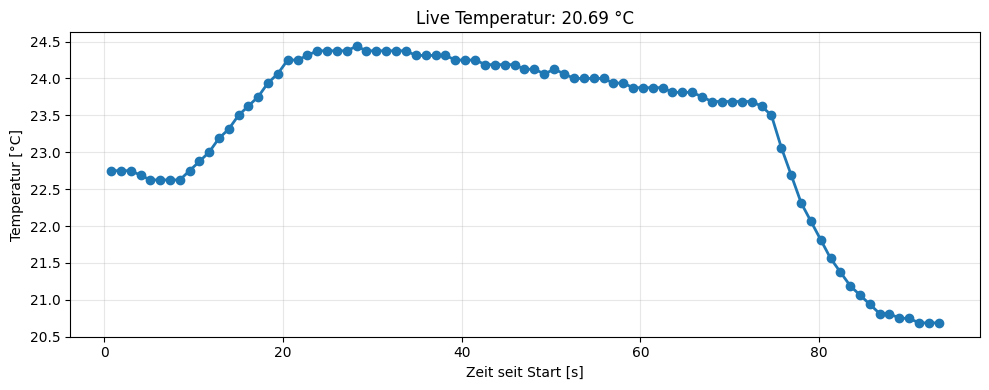

Letzter Wert: 20.688 °C
Zum Stoppen: oben im Notebook die Stop-Schaltflaeche druecken.
Live-Plot gestoppt.


In [4]:
# Einstellungen
messabstand = 0.2      # Sekunden zwischen zwei Messungen
max_punkte = 120       # So viele Punkte bleiben im Plot sichtbar

zeiten = []
temperaturen = []
start = time.time()

try:
    while True:
        # get_temp() startet intern jedes Mal convert_temp() neu.
        temp = my_pico.get_temp(pico)
        sekunden = time.time() - start

        zeiten.append(sekunden)
        temperaturen.append(temp)

        # Nur die letzten Werte anzeigen, damit der Plot uebersichtlich bleibt.
        plot_zeiten = zeiten[-max_punkte:]
        plot_temperaturen = temperaturen[-max_punkte:]

        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.plot(plot_zeiten, plot_temperaturen, marker="o", linewidth=2)
        plt.title(f"Live Temperatur: {temp:.2f} °C")
        plt.xlabel("Zeit seit Start [s]")
        plt.ylabel("Temperatur [°C]")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Letzter Wert: {temp:.3f} °C")
        print("Zum Stoppen: oben im Notebook die Stop-Schaltflaeche druecken.")

        time.sleep(messabstand)

except KeyboardInterrupt:
    print("Live-Plot gestoppt.")

## Verbindung trennen

In [5]:
# Diese Zelle ausfuehren, wenn du fertig bist.
my_pico.disconnect(pico)